# This file plots the reults of the outputs
Copy the output from **Send_Data_BP.ipynb** file to **Result_BP.txt**,

and do the same from **Send_Data_FF.ipynb** file to **Result_FF.txt** and run the cells below

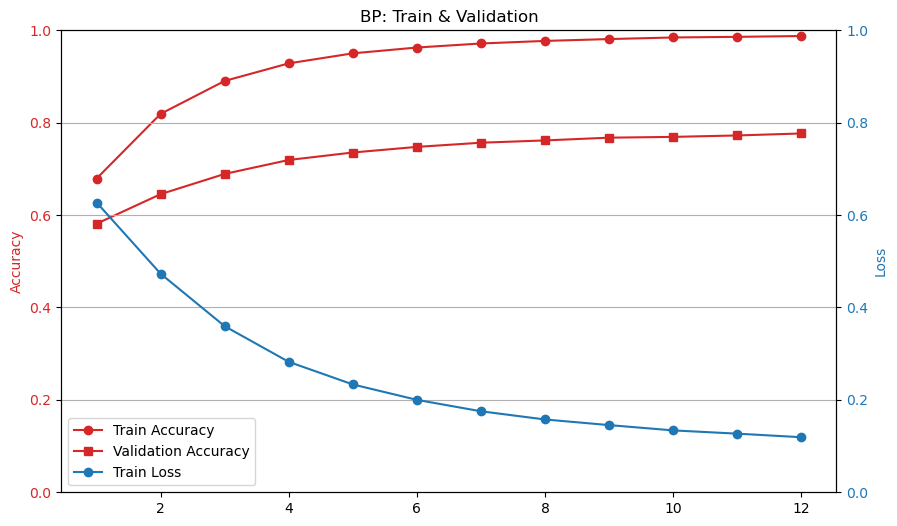

In [44]:
import re
import matplotlib.pyplot as plt

with open("Result_BP.txt", "r", encoding="utf-8") as f:
    text = f.read()

winacc = list(map(float, re.findall(r"WinAcc\(5000\): ([0-9.]+)", text)))
winloss = list(map(float, re.findall(r"WinAvgLoss\(5000\): ([0-9.]+)", text)))
stm_acc = list(map(float, re.findall(r"STM32 inference accuracy = ([0-9.]+)", text)))

def group_avg(data, group_size=6):
    return [
        sum(data[i:i+group_size]) / group_size
        for i in range(0, len(data), group_size)
        if len(data[i:i+group_size]) == group_size
    ]

winacc_avg = group_avg(winacc)
winloss_avg = group_avg(winloss)

min_len = min(len(winacc_avg), len(winloss_avg), len(stm_acc))
winacc_avg = winacc_avg[:min_len]
winloss_avg = winloss_avg[:min_len]
stm_acc = stm_acc[:min_len]


x = list(range(1, min_len + 1))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis - Accuracy 
ax1.plot(x, winacc_avg, marker='o', color='tab:red', label='Train Accuracy')
ax1.plot(x, stm_acc, marker='s', color='tab:red', label='Validation Accuracy')
ax1.set_ylabel("Accuracy", color='tab:red')
ax1.set_ylim([0, 1])
ax1.tick_params(axis='y', labelcolor='tab:red')

# Right axis - Loss
ax2 = ax1.twinx()
ax2.plot(x, winloss_avg, marker='o', color='tab:blue', label='Train Loss')
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss", color='tab:blue')
ax2.set_ylim([0, 1])
ax2.tick_params(axis='y', labelcolor='tab:blue')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.title("BP: Train & Validation")
plt.grid()
plt.show()

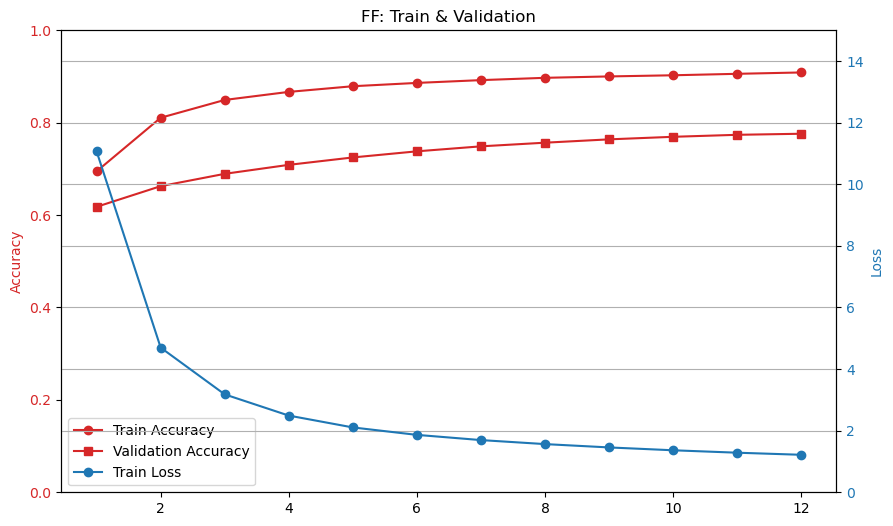

In [56]:
import re
import matplotlib.pyplot as plt

with open("Result_FF.txt", "r", encoding="utf-8") as f:
    text = f.read()

winacc = list(map(float, re.findall(r"WinAcc\(5000\): ([0-9.]+)", text)))
winloss = list(map(float, re.findall(r"WinAvgLoss\(5000\): ([0-9.]+)", text)))
stm_acc = list(map(float, re.findall(r"STM32 inference accuracy = ([0-9.]+)", text)))

def group_avg(data, group_size=6):
    return [
        sum(data[i:i+group_size]) / group_size
        for i in range(0, len(data), group_size)
        if len(data[i:i+group_size]) == group_size
    ]

winacc_avg = group_avg(winacc)
winloss_avg = group_avg(winloss)

min_len = min(len(winacc_avg), len(winloss_avg), len(stm_acc))
winacc_avg = winacc_avg[:min_len]
winloss_avg = winloss_avg[:min_len]
stm_acc = stm_acc[:min_len]


x = list(range(1, min_len + 1))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis - Accuracy 
ax1.plot(x, winacc_avg, marker='o', color='tab:red', label='Train Accuracy')
ax1.plot(x, stm_acc, marker='s', color='tab:red', label='Validation Accuracy')
ax1.set_ylabel("Accuracy", color='tab:red')
ax1.set_ylim([0, 1])
ax1.tick_params(axis='y', labelcolor='tab:red')

# Right axis - Loss
ax2 = ax1.twinx()
ax2.plot(x, winloss_avg, marker='o', color='tab:blue', label='Train Loss')
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss", color='tab:blue')
ax2.set_ylim([0, 15])
ax2.tick_params(axis='y', labelcolor='tab:blue')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.title("FF: Train & Validation")
plt.grid()
plt.show()